# IMPORTS

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt
import time
import os
import copy
from torch.utils import data
from PIL import Image
import random
import cv2
import json
import datetime
import multiprocessing
import queue
import threading

from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection import FasterRCNN
from torchvision.models.detection.rpn import AnchorGenerator
from torchvision.models.detection.faster_rcnn import FasterRCNN_ResNet50_FPN_Weights # ADDED THIS LINE

from torchvision.datasets import CocoDetection
from torch.utils.data import DataLoader, Dataset

from pycocotools.coco import COCO

import os

to_tensor = torchvision.transforms.ToTensor()

print("PyTorch Version: ",torch.__version__)
print("Torchvision Version: ",torchvision.__version__)

PyTorch Version:  2.9.1+rocmsdk20251207
Torchvision Version:  0.24.0+rocmsdk20251207


In [ ]:
!python generate.py 1024

# PREPARING DATA

In [ ]:
# Custom PyTorch Dataset to load COCO-format annotations and images
class CocoDetectionDataset(Dataset):
    # Init function: loads annotation file and prepares list of image IDs
    def __init__(self, image_dir, annotation_path, transforms=None):
        self.image_dir = image_dir
        self.coco = COCO(annotation_path)
        self.image_ids = list(self.coco.imgs.keys())
        self.transforms = transforms

    # Returns total number of images
    def __len__(self):
        return len(self.image_ids)

    # Fetches a single image and its annotations
    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        image_info = self.coco.loadImgs(image_id)[0]
        image_path = os.path.join(self.image_dir, image_info['file_name'])
        image = Image.open(image_path).convert("RGB")

        # Load all annotations for this image
        annotation_ids = self.coco.getAnnIds(imgIds=image_id)
        annotations = self.coco.loadAnns(annotation_ids)

        # Extract bounding boxes and labels from annotations
        boxes = []
        labels = []
        for obj in annotations:
            xmin, ymin, width, height = obj['bbox']
            xmax = xmin + width
            ymax = ymin + height
            boxes.append([xmin, ymin, xmax, ymax])
            labels.append(obj['category_id'])

        # Convert annotations to PyTorch tensors
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.as_tensor(labels, dtype=torch.int64)
        area = torch.as_tensor([obj['area'] for obj in annotations], dtype=torch.float32)
        iscrowd = torch.as_tensor([obj.get('iscrowd', 0) for obj in annotations], dtype=torch.int64)

        # Package everything into a target dictionary
        target = {
            "boxes": boxes,
            "labels": labels,
            "image_id": image_id,
            "area": area,
            "iscrowd": iscrowd
        }

        # Apply transforms if any were passed
        if self.transforms:
            image = self.transforms(image)

        return image, target

In [ ]:
train_dataset = CocoDetectionDataset(image_dir="dataset/images/train",
                               annotation_path="dataset/instances_train.json")

val_dataset = CocoDetectionDataset(image_dir="dataset/images/val",
                               annotation_path="dataset/instances_val.json")

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


In [ ]:
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, collate_fn=lambda x: tuple(zip(*x)))

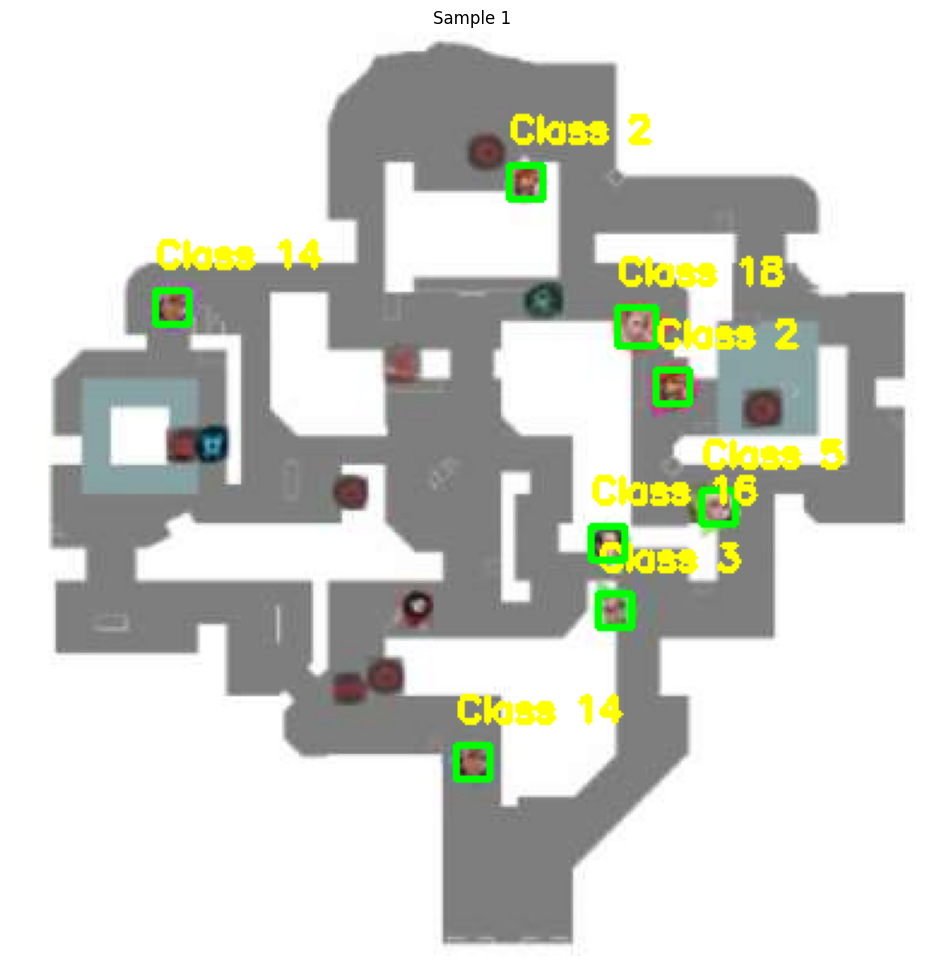

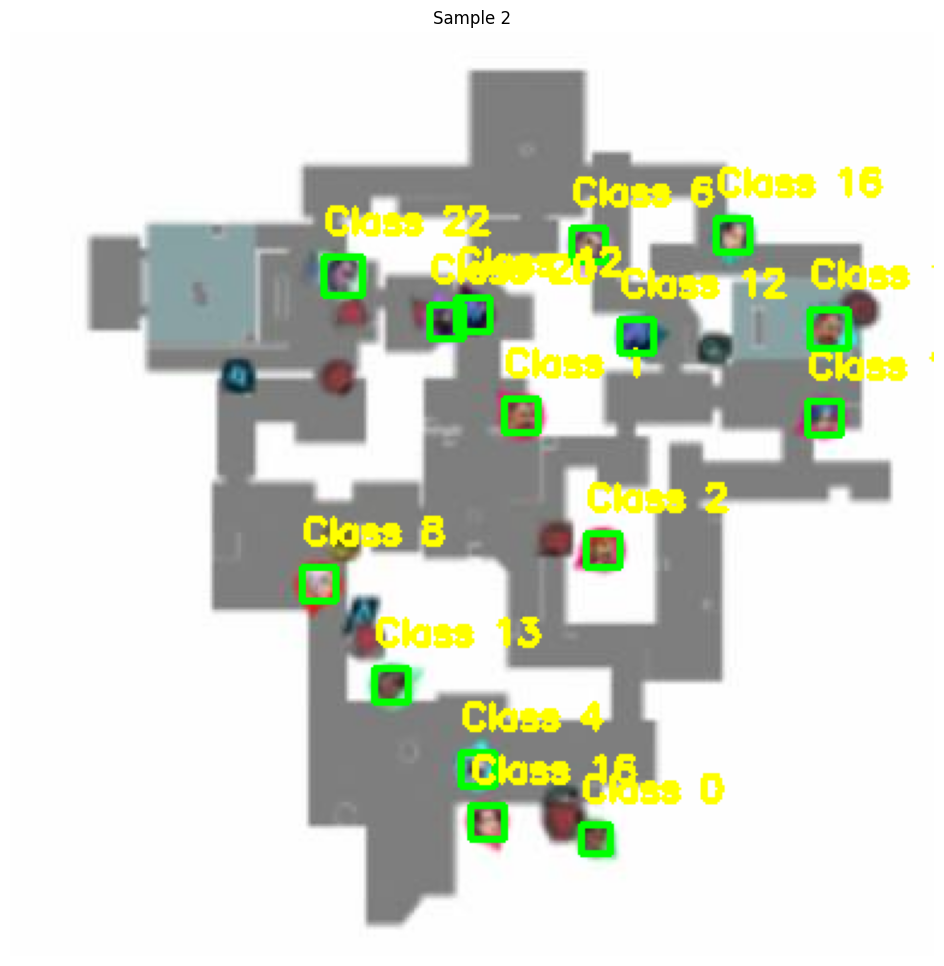

In [ ]:
# Get one batch from the DataLoader
images, targets = next(iter(train_loader))

to_tensor = transforms.ToTensor()

# Convert PIL Image and draw annotations
for i in range(len(images)):
    image = to_tensor(images[i]).permute(1, 2, 0).numpy()  # Convert from CxHxW to HxWxC
    image = (image * 255).astype(np.uint8)  # Rescale
    image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)

    boxes = targets[i]['boxes']
    labels = targets[i]['labels']

    for box, label in zip(boxes, labels):
        x1, y1, x2, y2 = map(int, box.tolist())
        cv2.rectangle(image, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(image, f"Class {label.item()}", (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 255), 2)

    # Show image with boxes using matplotlib
    plt.figure(figsize=(16, 12))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"Sample {i + 1}")
    plt.show()

# GETTING STUFF SET UP FOR TRAINING

In [ ]:
niter = 0
print_freq = 10
save_freq = 1000
num_epochs = 10

for epoch in range(num_epochs):
    print(f"Processing {epoch + 1}/{num_epochs}")
    # Set model to train mode for this demonstration
    model.train()
    optimizer.zero_grad() # Clear gradients for the current batch

    for batch_idx, (imgs, annotations_batch) in enumerate(train_loader):
        # 1. Process images: Convert PIL images to tensors and move to device
        input_images = [to_tensor(img).to(device) for img in imgs]

        # 2. Process annotations (targets): Move tensors within each target dictionary to device
        # This is the corrected part from the previous error (ValueError).
        input_data = [{k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in t.items()} for t in annotations_batch]

        # 3. Perform a forward pass and calculate losses
        loss_dict = model(input_images, input_data)
        losses = sum(loss for loss in loss_dict.values())

        # 4. Backward pass and optimizer step
        losses.backward()
        optimizer.step()
        optimizer.zero_grad()

        # 5. Print losses
        if batch_idx % print_freq == 0:
            print(f"Batch: {batch_idx}, Loss: {losses.item():.4f}")

    scheduler.step()


Epoch 1/1
Epoch: [0]  [ 0/64]  eta: 0:00:02  lr: 0.000084  loss: 0.0000 (0.0000)  loss_classifier: 0.0000 (0.0000)  loss_box_reg: 0.0000 (0.0000)  loss_objectness: 0.0000 (0.0000)  loss_rpn_box_reg: 0.0000 (0.0000)  time: 0.0390  data: 0.0030  max mem: 1610
Epoch: [0]  [25/64]  eta: 0:00:01  lr: 0.002066  loss: 0.0000 (0.0000)  loss_classifier: 0.0000 (0.0000)  loss_box_reg: 0.0000 (0.0000)  loss_objectness: 0.0000 (0.0000)  loss_rpn_box_reg: 0.0000 (0.0000)  time: 0.0354  data: 0.0032  max mem: 1610
Epoch: [0]  [50/64]  eta: 0:00:00  lr: 0.004049  loss: 0.0000 (0.0000)  loss_classifier: 0.0000 (0.0000)  loss_box_reg: 0.0000 (0.0000)  loss_objectness: 0.0000 (0.0000)  loss_rpn_box_reg: 0.0000 (0.0000)  time: 0.0368  data: 0.0032  max mem: 1616
Epoch: [0]  [63/64]  eta: 0:00:00  lr: 0.005000  loss: 0.0000 (0.0000)  loss_classifier: 0.0000 (0.0000)  loss_box_reg: 0.0000 (0.0000)  loss_objectness: 0.0000 (0.0000)  loss_rpn_box_reg: 0.0000 (0.0000)  time: 0.0354  data: 0.0030  max mem: 161

AttributeError: 'Image' object has no attribute 'shape'

In [10]:
img_path = "dataset/images/train/0001.png"
image_bgr = cv2.imread(img_path)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
image_pil = Image.fromarray(image_rgb)


In [11]:
# Transform image
transform = transforms.Compose([transforms.ToTensor()])
image_tensor = transform(image_pil).unsqueeze(0)

In [13]:
with torch.no_grad():
    predictions = model(image_tensor.to(device))

# results

In [2]:
img_path = "dataset/images/train/0001.png"
image_bgr = cv2.imread(img_path)
image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
image_pil = Image.fromarray(image_rgb)


NameError: name 'cv2' is not defined

In [ ]:
# Transform image
transform = transforms.Compose([transforms.ToTensor()])
image_tensor = transform(image_pil).unsqueeze(0)

In [ ]:
model.eval()  # Set the model to evaluation mode
with torch.no_grad():
    predictions = model(image_tensor.to(device))

In [ ]:
model.eval()  # Set the model to evaluation mode
with torch.no_grad():
    predictions = model(image_tensor.to(device))

In [ ]:
def show_prediction(prediction, image_bgr):
  boxes = prediction['boxes']
  labels = prediction['labels']
  scores = prediction['scores']

  print(f"Raw scores: {scores}")
  print(f"Raw labels: {labels}")

  #label_list = [f"Agent_{i}" for i in range(1, 23)] # Assuming class IDs are 1-22 for agents
  label_list = ["Chamber",
              "Cypher",
              "Yoru",
              "Killjoy",
              "KAYO",
              "Gekko",
              "Astra",
              "Deadlock",
              "Breach",
              "Omen",
              "Reyna",
              "Phoenix",
              "Tejo",
              "Raze",
              "Brimstone",
              "Vyse",
              "Fade",
              "Sova",
              "Jett",
              "Neon",
              "Skye",
              "Viper",
              "Sage"]

  # Threshold
  threshold = 0.5

  # Keep track of whether any boxes were drawn
  b_boxes_drawn = False

  for i in range(len(boxes)):
      if scores[i] > threshold:
          box = boxes[i].cpu().numpy().astype(int)
          label_id = labels[i].item() # Get integer value of label
          # Ensure label_id is within the valid range for label_list
          if 0 < label_id <= len(label_list):
              label = label_list[label_id] # Adjust index if label_list is 0-indexed
          else:
              label = f"Unknown ({label_id})"

          score = scores[i].item()

          # draw label and score
          text = f"{label}: {score:.2f}"
          cv2.putText(image_bgr, text, (box[0], box[1] - 10), cv2.FONT_HERSHEY_SIMPLEX,
                      0.4, (0, 0, 0), 3, cv2.LINE_AA)
          cv2.putText(image_bgr, text, (box[0], box[1] - 10), cv2.FONT_HERSHEY_SIMPLEX,
                      0.4, (0, 255, 0), 2, cv2.LINE_AA)

          # Draw rectangle and label
          cv2.rectangle(image_bgr, (box[0], box[1]), (box[2], box[3]), (0, 0, 255), 2)
          b_boxes_drawn = True

  # Check if any bounding boxes were drawn, if not, indicate it
  if not b_boxes_drawn:
      print(f"No bounding boxes detected above threshold {threshold}.")

  # Convert BGR to RGB for correct display with matplotlib
  image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

  # Show image with larger figure size
  plt.figure(figsize=(16, 12))  # Increase size as needed
  plt.imshow(image_rgb)
  plt.axis('off')
  plt.show()

In [ ]:
def make_prediction(model, img_path):
  image_bgr = cv2.imread(img_path)
  image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
  image_pil = Image.fromarray(image_rgb)

  # Transform image
  transform = transforms.Compose([transforms.ToTensor()])
  image_tensor = transform(image_pil).unsqueeze(0)

  model.eval()  # Set the model to evaluation mode
  with torch.no_grad():
      predictions = model(image_tensor.to(device))

  show_prediction(predictions[0], image_bgr)

In [ ]:
images = ["snippet.png", "snippet2.png", "snippet3.png", "snippet4.png", "snippet5.png"]
for image in images:
  make_prediction(model=model, img_path=image)